# 01 . Vasicek calibration to Fed rate data (Part I a)

$$dr(t) = a\,(b - r(t))\,dt + \sigma\,dW(t)$$

The exact discretisation over a step $\Delta t$ is an AR(1) process

$$r_{t+\Delta t} = \alpha\, r_t + \beta + \epsilon_t,\qquad \epsilon_t \sim N(0, s^2),$$

with $\alpha = e^{-a\Delta t}$, $\beta = b(1-\alpha)$, $s^2 = \frac{\sigma^2}{2a}(1-\alpha^2)$.
OLS on $(r_t, r_{t+\Delta t})$ gives $\hat\alpha, \hat\beta, \hat s$, and

$$\hat a = -\frac{\ln\hat\alpha}{\Delta t},\qquad \hat b = \frac{\hat\beta}{1-\hat\alpha},\qquad
\hat\sigma = \hat s\sqrt{\frac{2\hat a}{1-e^{-2\hat a\Delta t}}}.$$

The loader in `src/calibration.py` is generic: any FRED series id, any CSV URL / file with
`(date, rate)` columns, and any `[start, end]` window.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:.6f}".format

In [2]:
from calibration import (FRED_URL, fetch_fed_rates, load_rates, calibrate_vasicek,
                         rolling_calibration, expected_rate, rate_std, rate_at)

# Daily Effective Federal Funds Rate (DFF), full history; cached to data/
dff = fetch_fed_rates("DFF", start=None)
print(FRED_URL.format(series="DFF"))
print(f"{len(dff):,} observations, {dff.index[0].date()} to {dff.index[-1].date()}")
dff.tail()

https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF
26,391 observations, 1954-07-01 to 2026-10-01


date
2026-09-27   0.038800
2026-09-28   0.038800
2026-09-29   0.038800
2026-09-30   0.038800
2026-10-01   0.038800
Name: rate, dtype: float64

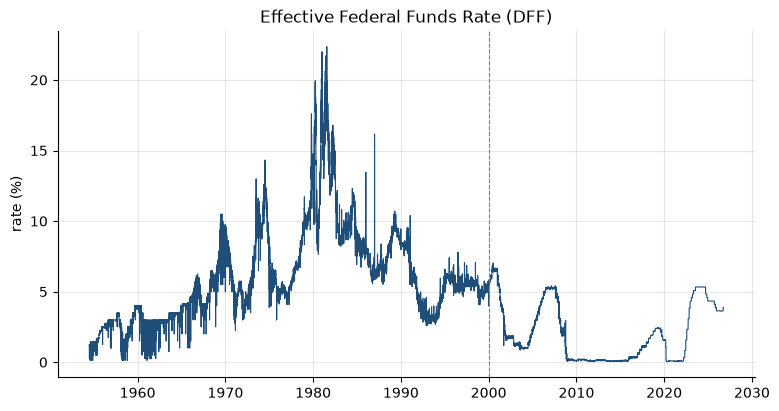

In [3]:
fig, ax = plt.subplots()
ax.plot(dff.index, dff * 100, lw=0.8, color="#1f4e79")
ax.axvline(pd.Timestamp("2000-01-01"), color="grey", ls="--", lw=0.8)
ax.set_title("Effective Federal Funds Rate (DFF)")
ax.set_ylabel("rate (%)")
plt.show()

## Calibration on the main window (2000 to latest)

In [4]:
r = dff.loc["2000-01-01":]
fit = calibrate_vasicek(r)

pd.Series({
    "window": f"{r.index[0].date()} to {r.index[-1].date()}",
    "observations": fit["n_obs"],
    "dt (years)": f"1/{1 / fit['dt']:.0f}",
    "alpha": f"{fit['alpha']:.6f}",
    "beta": f"{fit['beta']:.3e}",
    "s": f"{fit['s']:.3e}",
    "a (mean-reversion speed)": f"{fit['a']:.4f}",
    "half-life ln2/a (years)": f"{fit['half_life']:.2f}",
    "b (long-run mean)": f"{fit['b']:.4%}",
    "sigma (volatility)": f"{fit['sigma']:.4%}",
    "r(latest)": f"{fit['r_last']:.4%}",
}).to_frame("value")

,value
window,2000-01-01 to 2026-10-01
observations,9771
dt (years),1/365
alpha,0.999480
beta,1.057e-05
s,6.487e-04
a (mean-reversion speed),0.1900
half-life ln2/a (years),3.65
b (long-run mean),2.0320%
sigma (volatility),1.2397%


## Sensitivity to the estimation window

The OLS estimate of $a$ is notoriously noisy (the AR(1) coefficient is close to 1 for daily
data), so the parameters depend on the window. `calibrate_vasicek` raises an error when a window
shows no mean reversion ($\hat\alpha \ge 1$).

In [5]:
windows = {"2000 - latest": ("2000-01-01", None),
           "2000 - 2024 (report)": ("2000-01-01", "2024-12-31"),
           "2010 - latest": ("2010-01-01", None),
           "1990 - 2024": ("1990-01-01", "2024-12-31"),
           "2015 - latest": ("2015-01-01", None)}
rows = {}
for name, (s, e) in windows.items():
    try:
        p = calibrate_vasicek(dff.loc[s:e])
        rows[name] = {"a": p["a"], "half-life (y)": p["half_life"], "b": p["b"], "sigma": p["sigma"]}
    except ValueError as err:
        rows[name] = {"a": np.nan, "half-life (y)": np.nan, "b": np.nan, "sigma": np.nan}
        print(name, "->", err)
pd.DataFrame(rows).T.style.format({"a": "{:.4f}", "half-life (y)": "{:.2f}",
                                   "b": "{:.3%}", "sigma": "{:.3%}"})

,a,half-life (y),b,sigma
2000 - latest,0.1900,3.65,2.032%,1.240%
2000 - 2024 (report),0.1924,3.60,1.990%,1.278%
2010 - latest,0.0248,28.00,10.749%,0.609%
1990 - 2024,0.7621,0.91,2.704%,2.803%
2015 - latest,0.0841,8.24,5.971%,0.717%


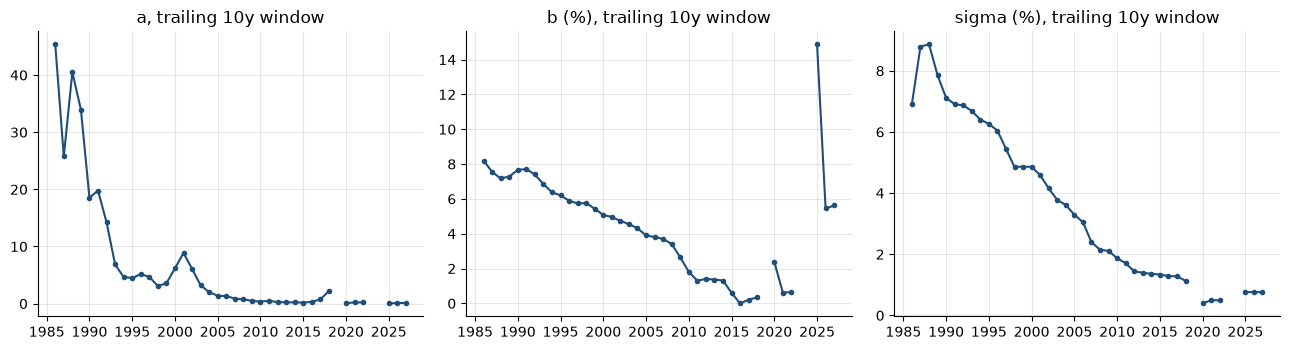

In [6]:
roll = rolling_calibration(dff.loc["1985-01-01":], window_years=10)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, scale, lab in zip(axes, ["a", "b", "sigma"], [1, 100, 100], ["a", "b (%)", "sigma (%)"]):
    ax.plot(roll.index, roll[col] * scale, marker="o", ms=3, color="#1f4e79")
    ax.set_title(f"{lab}, trailing 10y window")
plt.tight_layout()
plt.show()

## Generating values at any point

* `rate_at(series, date)` returns the observed rate on any date (last value on or before it).
* The calibrated model gives the distribution of the rate at any future horizon:
  $E[r(t)] = r_0 e^{-at} + b(1-e^{-at})$, $\;\mathrm{Var}[r(t)] = \frac{\sigma^2}{2a}(1-e^{-2at})$.

DFF on 2008-09-15: 2.6400%
DFF on 2020-03-16: 0.2500%
DFF on 2023-08-01: 5.3300%
DFF on 2025-12-25: 3.6400%


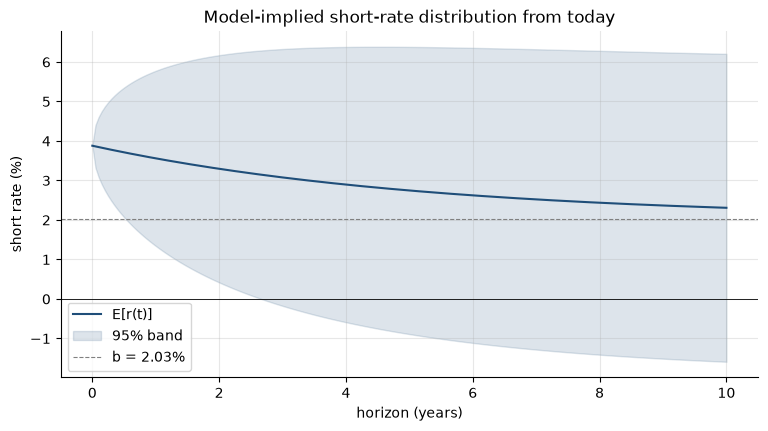

,E[r(t)],std
t (years),,
1,3.5603%,1.1308%
2,3.2959%,1.4674%
5,2.7468%,1.8548%
10,2.3085%,1.9887%


In [7]:
for d in ["2008-09-15", "2020-03-16", "2023-08-01", "2025-12-25"]:
    print(f"DFF on {d}: {rate_at(dff, d):.4%}")

a, b, sigma, r0 = fit["a"], fit["b"], fit["sigma"], fit["r_last"]
h = np.linspace(0, 10, 201)
m, sd = expected_rate(r0, h, a, b), rate_std(h, a, sigma)

fig, ax = plt.subplots()
ax.plot(h, m * 100, color="#1f4e79", label="E[r(t)]")
ax.fill_between(h, (m - 1.96 * sd) * 100, (m + 1.96 * sd) * 100, color="#1f4e79", alpha=0.15,
                label="95% band")
ax.axhline(b * 100, color="grey", ls="--", lw=0.8, label=f"b = {b:.2%}")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("horizon (years)"); ax.set_ylabel("short rate (%)")
ax.set_title("Model-implied short-rate distribution from today")
ax.legend(); plt.show()

pd.DataFrame({"E[r(t)]": expected_rate(r0, [1, 2, 5, 10], a, b),
              "std": rate_std(np.array([1, 2, 5, 10]), a, sigma)},
             index=pd.Index([1, 2, 5, 10], name="t (years)")).style.format("{:.4%}")

**Notes.** The Gaussian short rate can go negative (the band crosses zero), a known limitation
of Vasicek. The parameters here are the statistical (P-measure) estimates; we use them as
risk-neutral parameters, i.e. we assume a zero market price of risk.